In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_csv(r"C:\Users\bhosa\OneDrive\Desktop\PBL\dataset\cleaned_dataset_Thyroid1.csv")

df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
0,41.0,0.0,0,0,0,0,0,0,0,0,...,1,1.30,1,1,125.0,1.0,1.140,1,109.000000,0
1,23.0,0.0,0,0,0,0,0,0,0,0,...,1,4.10,1,1,102.0,0.0,0.995,0,110.469649,0
2,46.0,1.0,0,0,0,0,0,0,0,0,...,1,0.98,0,1,109.0,1.0,0.910,1,120.000000,0
3,70.0,0.0,1,0,0,0,0,0,0,0,...,1,0.16,1,1,175.0,0.0,0.995,0,110.469649,0
4,70.0,0.0,0,0,0,0,0,0,0,0,...,1,0.72,1,1,61.0,1.0,0.870,1,70.000000,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3771 entries, 0 to 3770
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3771 non-null   float64
 2   on thyroxine               3771 non-null   int64  
 3   query on thyroxine         3771 non-null   int64  
 4   on antithyroid medication  3771 non-null   int64  
 5   sick                       3771 non-null   int64  
 6   pregnant                   3771 non-null   int64  
 7   thyroid surgery            3771 non-null   int64  
 8   I131 treatment             3771 non-null   int64  
 9   query hypothyroid          3771 non-null   int64  
 10  query hyperthyroid         3771 non-null   int64  
 11  lithium                    3771 non-null   int64  
 12  goitre                     3771 non-null   int64  
 13  tumor                      3771 non-null   int64  
 14  hyp

In [6]:
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
count,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,...,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000
mean,51.628941,0.315379,0.123044,0.013259,0.011403,0.038982,0.014055,0.014055,0.015646,0.062053,...,0.902148,5.087823,0.796075,0.938743,108.316778,0.897375,0.994964,0.897905,110.471364,0.077168
std,18.980472,0.455393,0.328532,0.114397,0.106187,0.193577,0.117732,0.117732,0.124117,0.241283,...,0.297154,23.293851,0.402967,0.239833,34.500726,0.303509,0.185168,0.302813,31.359068,0.266893
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.005000,0.000000,0.000000,2.000000,0.000000,0.250000,0.000000,2.000000,0.000000
25%,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.600000,1.000000,1.000000,89.000000,1.000000,0.890000,1.000000,94.000000,0.000000
50%,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.600000,1.000000,1.000000,106.000000,1.000000,0.995000,1.000000,110.000000,0.000000
75%,67.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,3.800000,1.000000,1.000000,123.000000,1.000000,1.070000,1.000000,121.500000,0.000000
max,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,530.000000,1.000000,1.000000,430.000000,1.000000,2.320000,1.000000,395.000000,1.000000


In [7]:
df.isnull().sum()

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
binaryClass                  0
dtype: int64

In [8]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

In [9]:
df.fillna(df.mean(), inplace=True)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
0,41.0,0,0,0,0,0,0,0,0,0,...,1,1.300000,1,1,125.000000,1.0,1.140,1,109.000000,0
1,23.0,0,0,0,0,0,0,0,0,0,...,1,4.100000,1,1,102.000000,0.0,0.995,0,110.469649,0
2,46.0,2,0,0,0,0,0,0,0,0,...,1,0.980000,0,1,109.000000,1.0,0.910,1,120.000000,0
3,70.0,0,1,0,0,0,0,0,0,0,...,1,0.160000,1,1,175.000000,0.0,0.995,0,110.469649,0
4,70.0,0,0,0,0,0,0,0,0,0,...,1,0.720000,1,1,61.000000,1.0,0.870,1,70.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3766,30.0,0,0,0,0,0,0,0,0,0,...,0,5.086766,0,0,108.319345,0.0,0.995,0,110.469649,0
3767,68.0,0,0,0,0,0,0,0,0,0,...,1,1.000000,1,1,124.000000,1.0,1.080,1,114.000000,0
3768,74.0,0,0,0,0,0,0,0,0,0,...,1,5.100000,1,1,112.000000,1.0,1.070,1,105.000000,0
3769,72.0,2,0,0,0,0,0,0,0,0,...,1,0.700000,1,1,82.000000,1.0,0.940,1,87.000000,0


In [10]:
df.isnull().sum()

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
binaryClass                  0
dtype: int64

In [11]:
X = df.drop('binaryClass', axis=1)
y = df['binaryClass']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (3016, 25)
Testing size: (755, 25)


In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model Trained ✅")

Model Trained ✅


In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 99.60264900662251


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       697
           1       0.95      1.00      0.97        58

    accuracy                           1.00       755
   macro avg       0.98      1.00      0.99       755
weighted avg       1.00      1.00      1.00       755



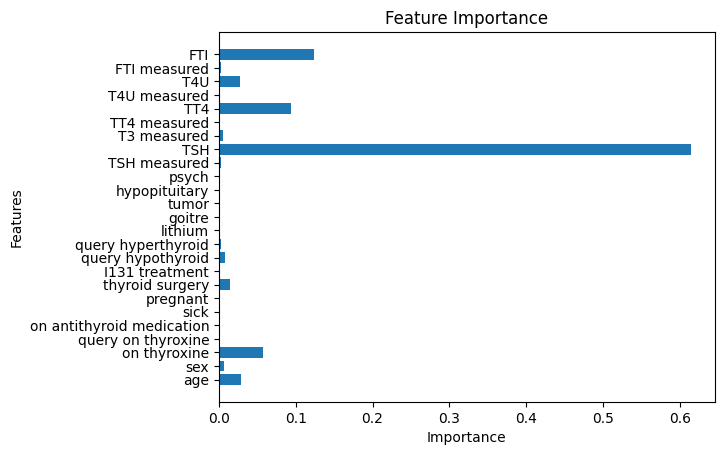

In [16]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [17]:
joblib.dump(model, "thyroid_model.pkl")

print("Model Saved ✅")

Model Saved ✅


In [20]:
sample_dict = {
    col: 0 for col in X.columns
}

# Fill only important values
sample_dict['age'] = 25
sample_dict['sex'] = 1
sample_dict['TSH'] = 2.5
sample_dict['TT4'] = 110
sample_dict['T4U'] = 1.1
sample_dict['FTI'] = 100

sample_df = pd.DataFrame([sample_dict])

prediction = model.predict(sample_df)
prob = model.predict_proba(sample_df)

print("Prediction:", prediction[0])
print("Confidence:", prob)

Prediction: 0
Confidence: [[1. 0.]]
